In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
pip install catboost xgboost


Defaulting to user installation because normal site-packages is not writeable
  Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl.metadata (1.5 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 1.0/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 1.3/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 1.8/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:51
   - -------------------------------------- 2.6/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 3.1/100.2 MB 1.9 MB/s eta 0:00:51
   - ---------------------

In [8]:
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neighbors  import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [9]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
# Preparaing X and Y vatriable 

X = df.drop(columns =['math score'], axis =1)

In [12]:
y = df['math score']

In [13]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [14]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [17]:
# Create Column Tranform with 3  types of transformers

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns


from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()


preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),

        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [18]:
X = preprocessor.fit_transform(X)

In [19]:
# separate dataset into train and test 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state =42)

X_train.shape, X_test.shape

((800, 19), (200, 19))

In [24]:
# create evaluate function to give all meatrics after model training

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted) 
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    
    return mae, mse, rmse, r2_square

In [28]:
#list all models into tuple
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting":CatBoostRegressor(verbose=False),
    "AdaBoost Regressor":AdaBoostRegressor()
}

model_list = []
r2_list =[]


for  i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)   # train models


    # make prediction 
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # evaluate the train and test dataset 
    #model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    #model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    # Added model_train_mse and model_test_mse to the unpacking
    

    print(list(model.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performace for training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error:{:.4f}".format(model_train_mae))
    print("- R2 Score {:.4f}".foramt(model_train_r2))

    print("---------------------------------")


    print("Model Performace for test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error:{:.4f}".format(model_test_mae))
    print("- R2 Score {:.4f}".foramt(model_test_r2))

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


    

AttributeError: 'LinearRegression' object has no attribute 'keys'

In [29]:
#list all models into tuple
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting":CatBoostRegressor(verbose=False),
    "AdaBoost Regressor":AdaBoostRegressor()
}

model_list = []
r2_list =[]


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)   # train models

    # make prediction 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # evaluate the train and test dataset 
    # Check what evaluate_model returns and adjust accordingly
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])  # Fixed: Changed model.keys() to models.keys()
    model_list.append(list(models.keys())[i])

    print("Model Performance for training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))  # Fixed: Changed foramt to format

    print("---------------------------------")

    print("Model Performance for test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))  # Fixed: Changed foramt to format

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model Performance for training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
---------------------------------
Model Performance for test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model Performance for training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
---------------------------------
Model Performance for test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253




C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

K-Neighbors Regressor
Model Performance for training set
- Root Mean Squared Error: 5.7133
- Mean Absolute Error: 4.5217
- R2 Score: 0.8552
---------------------------------
Model Performance for test set
- Root Mean Squared Error: 7.2412
- Mean Absolute Error: 5.6110
- R2 Score: 0.7845


Decision Tree
Model Performance for training set
- Root Mean Squared Error: 0.2795
- Mean Absolute Error: 0.0187
- R2 Score: 0.9997
---------------------------------
Model Performance for test set
- Root Mean Squared Error: 7.9492
- Mean Absolute Error: 6.2700
- R2 Score: 0.7403


Random Forest Regressor
Model Performance for training set
- Root Mean Squared Error: 2.2823
- Mean Absolute Error: 1.8278
- R2 Score: 0.9769
---------------------------------
Model Performance for test set
- Root Mean Squared Error: 5.9271
- Mean Absolute Error: 4.5961
- R2 Score: 0.8556


XGBRegressor
Model Performance for training set
- Root Mean Squared Error: 1.0073
- Mean Absolute Error: 0.6875
- R2 Score: 0.9955
-----

In [33]:
# results 
#pd.DataFrame(list(zip(model_list,r2_list)), columns = ["Model Name", "R2_Score"]).sort_values(
#    by = ["R2_score"],ascending = False)


In [34]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model Name", "R2_Score"]).sort_values(
    by=["R2_Score"], ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.880433
4,Random Forest Regressor,0.855631
6,CatBoosting,0.851632
7,AdaBoost Regressor,0.848287
5,XGBRegressor,0.827797
1,Lasso,0.825320
2,K-Neighbors Regressor,0.784518
3,Decision Tree,0.740320


In [36]:
# accuracy score 

lin_model = LinearRegression(fit_intercept=True)
lim_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
print(" Accuracy of the model is %.2f" % score)

 Accuracy of the model is 88.04


Text(0, 0.5, 'Predicted')

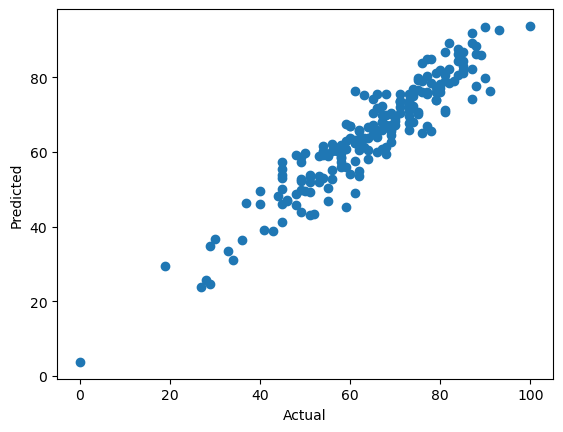

In [38]:
# plot yPred  yTest

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math score'>

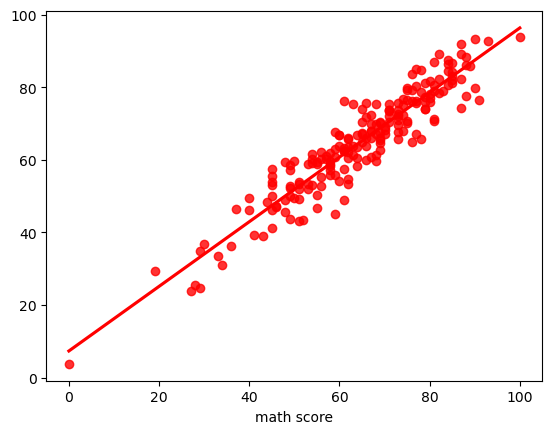

In [40]:
sns.regplot( x =y_test, y =y_pred, ci = None, color ='red')

In [41]:
# Difference between actual and predicted values

pred_df = pd.DataFrame({'Actual Values':y_test, 'Predicted Values': y_pred, 'Difference':y_test - y_pred})

In [42]:
pred_df.head()


,Actual Values,Predicted Values,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
